In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import numpy as np

In [2]:
# Stili ayarla
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

In [3]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

params = quote_plus(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=DESKTOP-DL6FE9F\\SQLEXPRESS;"
    "DATABASE=ECommerceDB;"
    "Trusted_Connection=yes;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

In [30]:
"""
-- ====================================================================
-- 1. EXPLORATORY DATA ANALYSIS (EDA) - VERİ KEŞIF ANALİZİ
-- ====================================================================
"""

query_1_1 = """
SELECT
    COUNT(*) AS total_records,
    COUNT(DISTINCT customer_id) AS unique_customers
FROM customers;
"""

customer_summary = pd.read_sql(query_1_1, engine)




query_1_2 = """
SELECT
    COUNT(*) AS total_orders,
    COUNT(DISTINCT Customer_Id) AS unique_customers
FROM Orders;
"""

order_summary = pd.read_sql(query_1_2, engine)





query_1_3_orders = """
SELECT *
FROM Orders;
"""

orders_df = pd.read_sql(query_1_3_orders, engine)





query_1_3_sellers = """
SELECT *
FROM order_seller_clean;
"""

seller_df = pd.read_sql(query_1_3_sellers, engine)





query_1_3_payment = """
SELECT *
FROM order_payment;
"""

payment_df = pd.read_sql(query_1_3_payment, engine)






query_1_4 = """
SELECT
    MIN(Order_Purchase_Timestamp) AS first_order,
    MAX(Order_Purchase_Timestamp) AS last_order
FROM Orders;
"""

date_range = pd.read_sql(query_1_4, engine)

# Tarihleri datetime tipine çevir
first_date = pd.to_datetime(date_range.loc[0, "first_order"])
last_date = pd.to_datetime(date_range.loc[0, "last_order"])

# Gün farkı
date_diff = (last_date - first_date).days




query_1_5 = """
SELECT *
FROM Orders
WHERE Customer_Id IS NULL;
"""

missing_customers = pd.read_sql(query_1_5, engine)






query_1_6 = """
SELECT
    SUM(payment_value) AS total_sales
FROM order_payment;
"""

total_sales = pd.read_sql(query_1_6, engine)


1.1 Müşteri Özeti:
   total_records  unique_customers
0          99441             99441


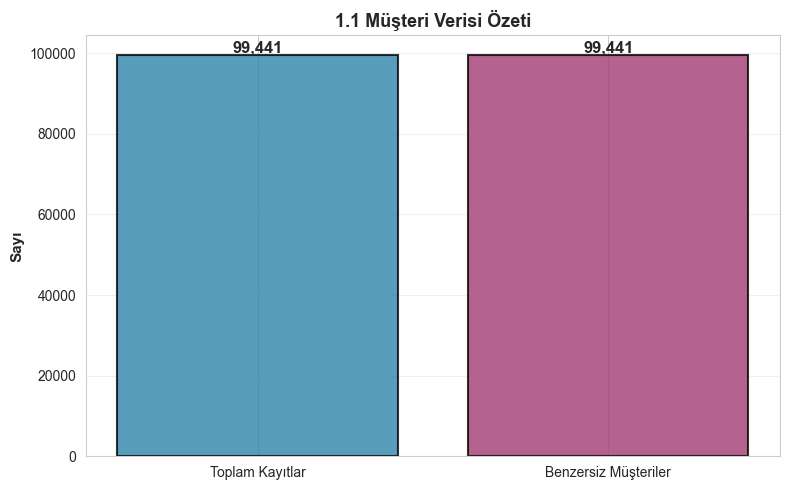

In [25]:
print("\n1.1 Müşteri Özeti:")
print(customer_summary)

fig, ax = plt.subplots(figsize=(8, 5))
data = [customer_summary['total_records'].values[0], 
        customer_summary['unique_customers'].values[0]]
labels = ['Toplam Kayıtlar', 'Benzersiz Müşteriler']
colors = ['#2E86AB', '#A23B72']

bars = ax.bar(labels, data, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Değerleri bar üzerine yazma
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Sayı', fontsize=11, fontweight='bold')
ax.set_title('1.1 Müşteri Verisi Özeti', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('01_customer_summary.png', dpi=300, bbox_inches='tight')
plt.show()


1.2 Sipariş Özeti:
   total_orders  unique_customers
0         99432             99432


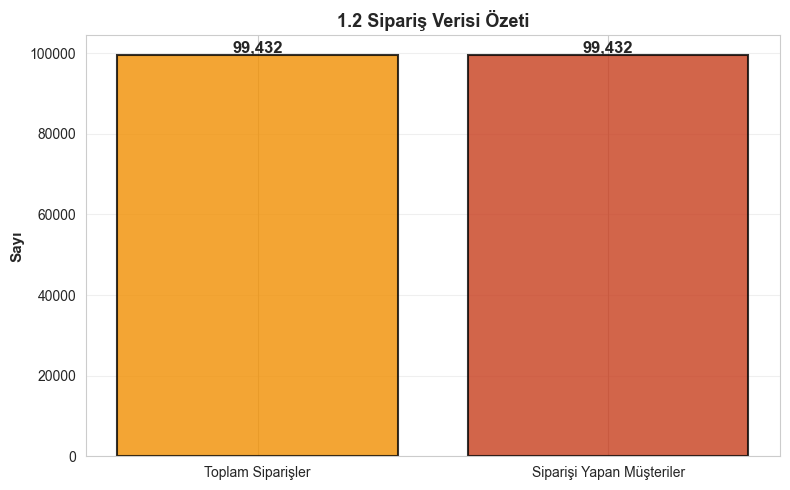

In [26]:
print("\n1.2 Sipariş Özeti:")
print(order_summary)

fig, ax = plt.subplots(figsize=(8, 5))
data = [order_summary['total_orders'].values[0], 
        order_summary['unique_customers'].values[0]]
labels = ['Toplam Siparişler', 'Siparişi Yapan Müşteriler']
colors = ['#F18F01', '#C73E1D']

bars = ax.bar(labels, data, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Değerleri bar üzerine yazma
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Sayı', fontsize=11, fontweight='bold')
ax.set_title('1.2 Sipariş Verisi Özeti', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('02_order_summary.png', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
print(info_text)


VERI ZAMAN ARALIGI

İlk Sipariş: 04 September 2016
Son Sipariş: 17 October 2018

Toplam Gün Sayısı: 772 gün
Toplam Yıl: 2.1 yıl



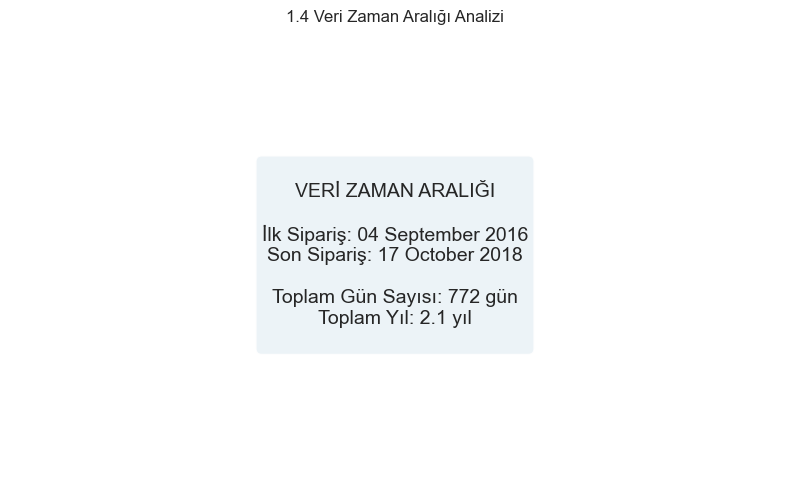

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))

info_text = f"""
VERİ ZAMAN ARALIĞI

İlk Sipariş: {first_date.strftime('%d %B %Y')}
Son Sipariş: {last_date.strftime('%d %B %Y')}

Toplam Gün Sayısı: {date_diff:,} gün
Toplam Yıl: {date_diff/365:.1f} yıl
"""

ax.text(
    0.5, 0.5,
    info_text,
    ha="center",
    va="center",
    fontsize=14,
    bbox=dict(boxstyle="round", facecolor="#E8F0F5", alpha=0.8)
)

ax.axis("off")
plt.title("1.4 Veri Zaman Aralığı Analizi")
plt.tight_layout()
plt.show()

In [13]:
"""
-- ====================================================================
-- 2. TEMPORAL ANALYSIS (ZAMANSELİ ANALİZ) - SATIŞLAR ZAMAN BOYUTUNDA
-- ====================================================================
"""
#-- 2.1 Yıllık Satış Trendleri
query_2_1 = """
SELECT
    YEAR(a1.Order_Purchase_Timestamp) as order_year,
    SUM(a2.payment_value) as total_sales,
    COUNT(DISTINCT a1.Customer_Id) as total_customers
FROM Orders a1
INNER JOIN order_payment a2 ON a1.Order_Id = a2.order_id
GROUP BY YEAR(a1.Order_Purchase_Timestamp)
ORDER BY YEAR(a1.Order_Purchase_Timestamp);
"""
yearly_sales = pd.read_sql(query_2_1, engine)




#-- 2.2 Aylık Satış Trendleri - Mevsimsellik Analizi
query_2_2="""
SELECT
    MONTH(a1.Order_Purchase_Timestamp) as order_month,
    SUM(a2.payment_value) as total_sales,
    COUNT(DISTINCT a1.Customer_Id) as total_customers
FROM Orders a1
INNER JOIN order_payment a2 ON a1.Order_Id = a2.order_id
GROUP BY MONTH(a1.Order_Purchase_Timestamp)
ORDER BY MONTH(a1.Order_Purchase_Timestamp);
"""
monthly_sales = pd.read_sql(query_2_2, engine)




#-- 2.3 Yıl ve Ay Kombinasyonu - Detaylı Zaman Serisi Analizi
query_2_3="""
SELECT
    YEAR(a1.Order_Purchase_Timestamp) as order_year,
    MONTH(a1.Order_Purchase_Timestamp) as order_month,
    SUM(a2.payment_value) as total_sales,
    COUNT(DISTINCT a1.Customer_Id) as total_customers
FROM Orders a1
INNER JOIN order_payment a2 ON a1.Order_Id = a2.order_id
GROUP BY YEAR(a1.Order_Purchase_Timestamp), MONTH(a1.Order_Purchase_Timestamp)
ORDER BY YEAR(a1.Order_Purchase_Timestamp), MONTH(a1.Order_Purchase_Timestamp);
"""
monthly_time_series = pd.read_sql(query_2_3, engine)





#-- 2.4 Aylık Toplam Satışlar - Aylar Bazında Performans (Alternatif Yazım)
query_2_4="""
SELECT
    DATETRUNC(month, a1.Order_Purchase_Timestamp) as order_date,
    SUM(a2.payment_value) as total_sales,
    COUNT(DISTINCT a1.Customer_Id) as total_customers
FROM Orders a1
INNER JOIN order_payment a2 ON a1.Order_Id = a2.order_id
GROUP BY DATETRUNC(month, a1.Order_Purchase_Timestamp)
ORDER BY DATETRUNC(month, a1.Order_Purchase_Timestamp);
"""
monthly_sales_date = pd.read_sql(query_2_4, engine)



2.1 Yıllık Satış Trendleri:
   order_year  total_sales  total_customers
0        2016     59362.34              328
1        2017   7249223.92            45098
2        2018   8698712.96            54005


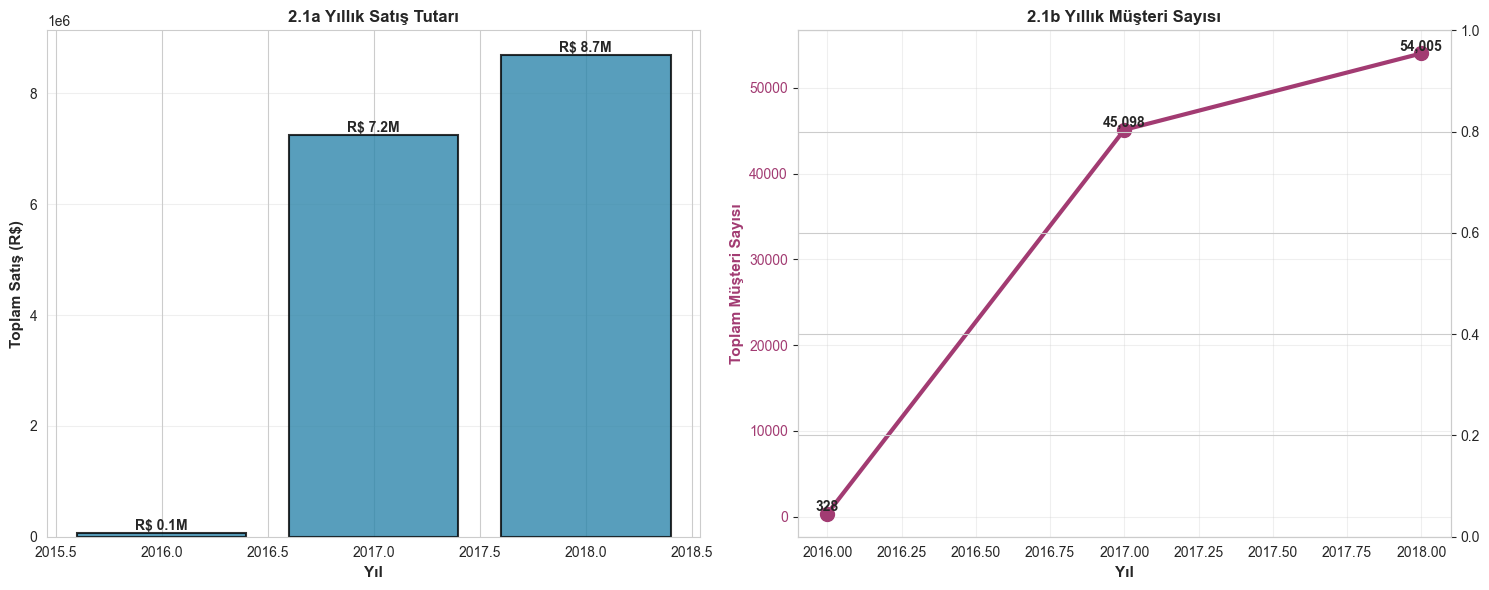

In [37]:
print("\n2.1 Yıllık Satış Trendleri:")
print(yearly_sales)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Satış grafiği
bars1 = ax1.bar(yearly_sales['order_year'], yearly_sales['total_sales'], 
                color='#2E86AB', alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Yıl', fontsize=11, fontweight='bold')
ax1.set_ylabel('Toplam Satış (R$)', fontsize=11, fontweight='bold')
ax1.set_title('2.1a Yıllık Satış Tutarı', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Değerleri bar üzerine yazma
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'R$ {height/1e6:.1f}M',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Müşteri sayısı grafiği
ax2_twin = ax2.twinx()

line = ax2.plot(yearly_sales['order_year'], yearly_sales['total_customers'], 
                marker='o', linewidth=3, markersize=10, color='#A23B72', label='Müşteri Sayısı')
ax2.set_xlabel('Yıl', fontsize=11, fontweight='bold')
ax2.set_ylabel('Toplam Müşteri Sayısı', fontsize=11, fontweight='bold', color='#A23B72')
ax2.set_title('2.1b Yıllık Müşteri Sayısı', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#A23B72')
ax2.grid(alpha=0.3)

# Değerleri nokta üzerine yazma
for x, y in zip(yearly_sales['order_year'], yearly_sales['total_customers']):
    ax2.text(x, y, f'{int(y):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('09_yearly_sales_trends.png', dpi=300, bbox_inches='tight')
plt.show()


2.2 Aylık Satış Trendleri - Mevsimsellik:
    order_month  total_sales  total_customers month_name
0             1   1253492.22             8069       Ocak
1             2   1284371.35             8508      Şubat
2             3   1609515.72             9893       Mart
3             4   1578573.51             9343      Nisan
4             5   1746706.97            10572      Mayıs
5             6   1534627.55             9409    Haziran
6             7   1658402.91            10315     Temmuz
7             8   1696821.64            10843    Ağustos
8             9    732260.25             4303      Eylül
9            10    839358.03             4959       Ekim
10           11   1194747.97             7543      Kasım
11           12    878421.10             5674     Aralık


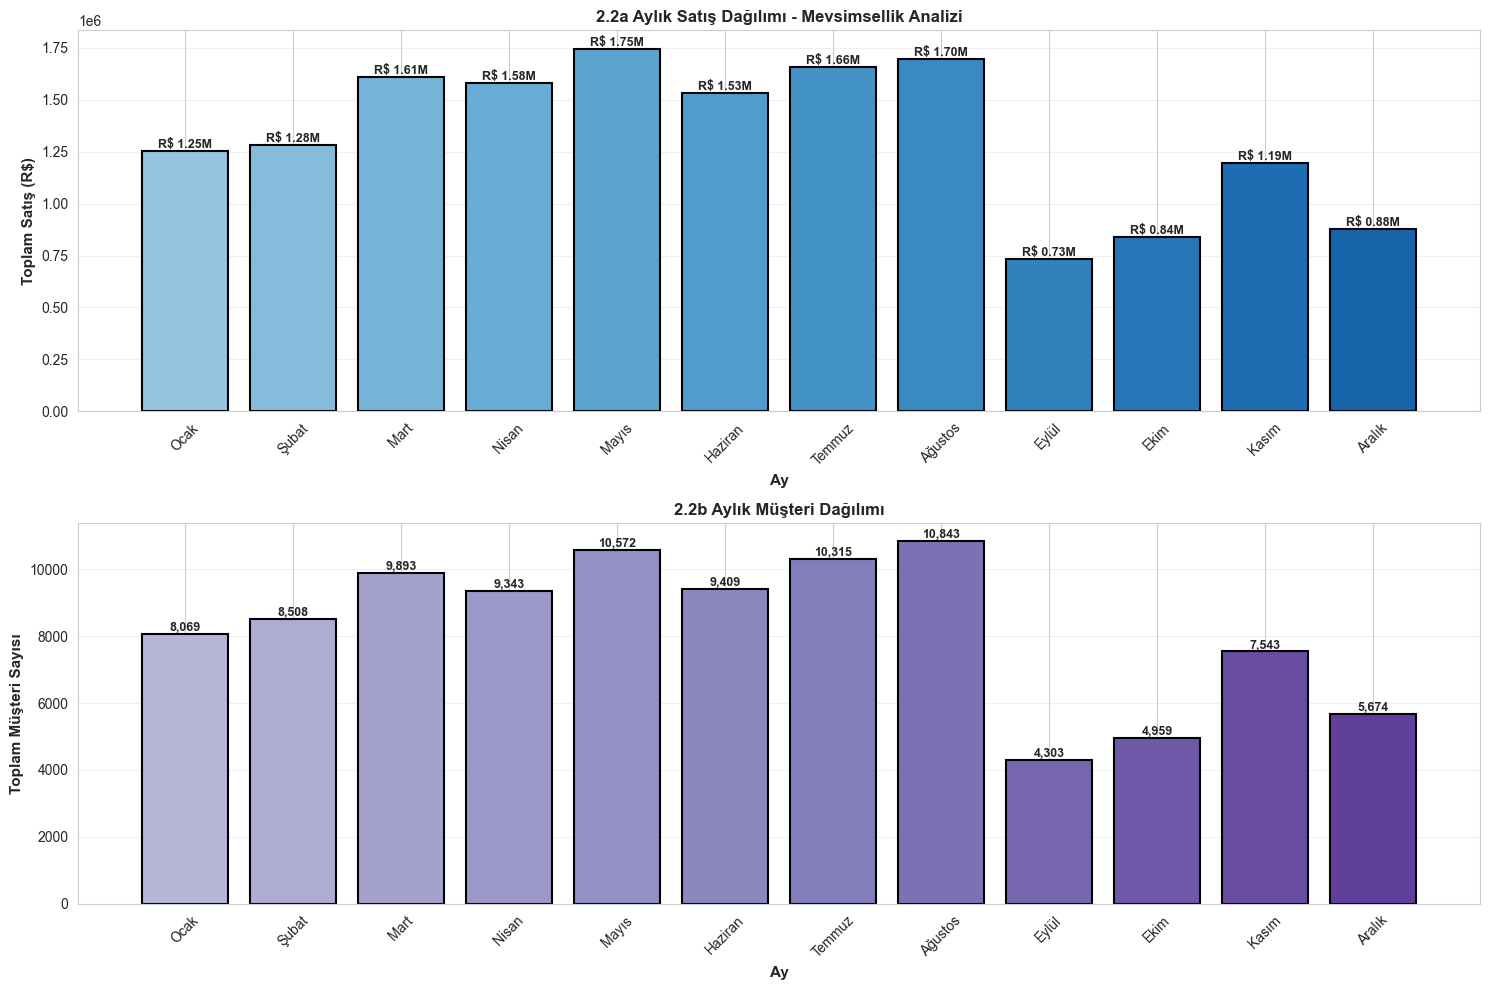

In [40]:
print("\n2.2 Aylık Satış Trendleri - Mevsimsellik:")
print(monthly_sales)

# Ay isimleri
month_names = ['Ocak', 'Şubat', 'Mart', 'Nisan', 'Mayıs', 'Haziran',
               'Temmuz', 'Ağustos', 'Eylül', 'Ekim', 'Kasım', 'Aralık']
monthly_sales['month_name'] = monthly_sales['order_month'].map(
    lambda x: month_names[x-1] if 1 <= x <= 12 else str(x)
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Satış grafiği
colors_gradient = plt.cm.Blues(np.linspace(0.4, 0.8, len(monthly_sales)))
bars = ax1.bar(monthly_sales['month_name'], monthly_sales['total_sales'], 
               color=colors_gradient, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Ay', fontsize=11, fontweight='bold')
ax1.set_ylabel('Toplam Satış (R$)', fontsize=11, fontweight='bold')
ax1.set_title('2.2a Aylık Satış Dağılımı - Mevsimsellik Analizi', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Değerleri bar üzerine yazma
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'R$ {height/1e6:.2f}M',
            ha='center', va='bottom', fontsize=9, fontweight='bold', rotation=0)

# Müşteri sayısı grafiği
colors_gradient2 = plt.cm.Purples(np.linspace(0.4, 0.8, len(monthly_sales)))
bars2 = ax2.bar(monthly_sales['month_name'], monthly_sales['total_customers'], 
                color=colors_gradient2, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Ay', fontsize=11, fontweight='bold')
ax2.set_ylabel('Toplam Müşteri Sayısı', fontsize=11, fontweight='bold')
ax2.set_title('2.2b Aylık Müşteri Dağılımı', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# Değerleri bar üzerine yazma
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('10_monthly_seasonality.png', dpi=300, bbox_inches='tight')
plt.show()


2.3 Yıl ve Ay Kombinasyonu - Detaylı Zaman Serisi:
   order_year  order_month  total_sales  total_customers
0        2016            9       252.24                3
1        2016           10     59090.48              324
2        2016           12        19.62                1
3        2017            1    138488.04              800
4        2017            2    291908.01             1780
5        2017            3    449863.60             2682
6        2017            4    417788.03             2404
7        2017            5    592724.82             3699
8        2017            6    511276.38             3245
9        2017            7    592382.92             4026


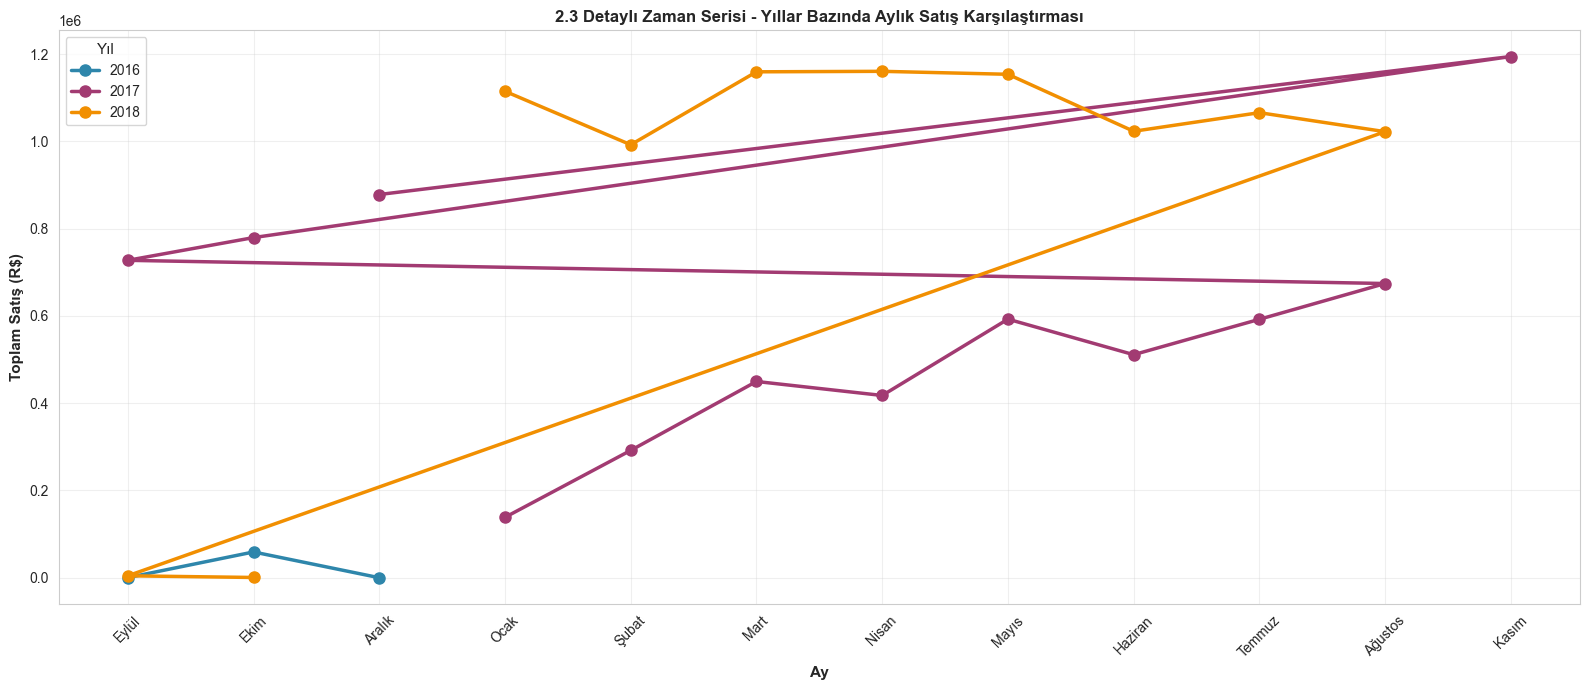

In [41]:
print("\n2.3 Yıl ve Ay Kombinasyonu - Detaylı Zaman Serisi:")
print(monthly_time_series.head(10))

# Yıllar grubuna göre
years = monthly_time_series['order_year'].unique()

fig, ax = plt.subplots(figsize=(16, 7))

# Her yıl için farklı renk
colors_map = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#06A77D']

for idx, year in enumerate(sorted(years)):
    year_data = monthly_time_series[monthly_time_series['order_year'] == year]
    month_names_filtered = [month_names[m-1] for m in year_data['order_month']]
    
    ax.plot(month_names_filtered, year_data['total_sales'], 
            marker='o', linewidth=2.5, markersize=8,
            label=f'{int(year)}', color=colors_map[idx % len(colors_map)])

ax.set_xlabel('Ay', fontsize=11, fontweight='bold')
ax.set_ylabel('Toplam Satış (R$)', fontsize=11, fontweight='bold')
ax.set_title('2.3 Detaylı Zaman Serisi - Yıllar Bazında Aylık Satış Karşılaştırması', 
             fontsize=12, fontweight='bold')
ax.legend(title='Yıl', fontsize=10, title_fontsize=11, loc='upper left')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('11_time_series_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


2.4 Aylık Toplam Satışlar - Zaman Serisi:
  order_date  total_sales  total_customers
0 2016-09-01       252.24                3
1 2016-10-01     59090.48              324
2 2016-12-01        19.62                1
3 2017-01-01    138488.04              800
4 2017-02-01    291908.01             1780
5 2017-03-01    449863.60             2682
6 2017-04-01    417788.03             2404
7 2017-05-01    592724.82             3699
8 2017-06-01    511276.38             3245
9 2017-07-01    592382.92             4026


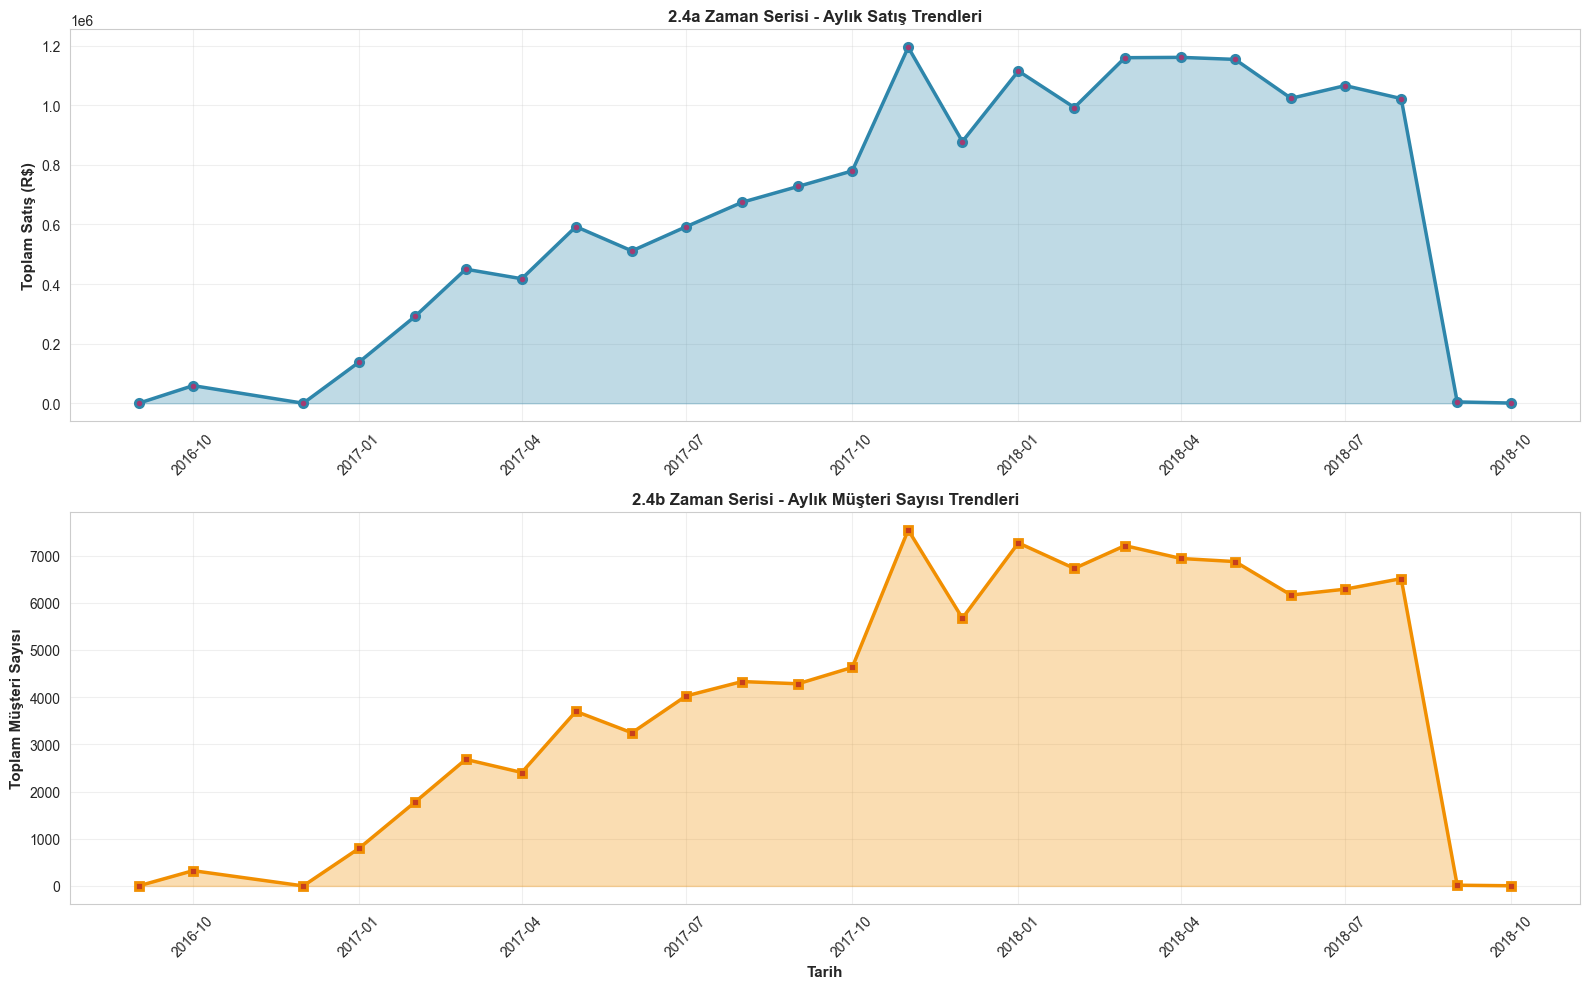

In [42]:
print("\n2.4 Aylık Toplam Satışlar - Zaman Serisi:")
print(monthly_sales_date.head(10))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Ana satış trendleri
ax1.plot(monthly_sales_date['order_date'], monthly_sales_date['total_sales'], 
         marker='o', linewidth=2.5, markersize=6, color='#2E86AB', 
         markerfacecolor='#A23B72', markeredgewidth=2, markeredgecolor='#2E86AB')
ax1.fill_between(monthly_sales_date['order_date'], monthly_sales_date['total_sales'], 
                 alpha=0.3, color='#2E86AB')
ax1.set_ylabel('Toplam Satış (R$)', fontsize=11, fontweight='bold')
ax1.set_title('2.4a Zaman Serisi - Aylık Satış Trendleri', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Müşteri trendleri
ax2.plot(monthly_sales_date['order_date'], monthly_sales_date['total_customers'], 
         marker='s', linewidth=2.5, markersize=6, color='#F18F01',
         markerfacecolor='#C73E1D', markeredgewidth=2, markeredgecolor='#F18F01')
ax2.fill_between(monthly_sales_date['order_date'], monthly_sales_date['total_customers'], 
                 alpha=0.3, color='#F18F01')
ax2.set_xlabel('Tarih', fontsize=11, fontweight='bold')
ax2.set_ylabel('Toplam Müşteri Sayısı', fontsize=11, fontweight='bold')
ax2.set_title('2.4b Zaman Serisi - Aylık Müşteri Sayısı Trendleri', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('12_monthly_time_series.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
"""
-- ====================================================================
-- 3. PAYMENT METHOD ANALYSIS (ÖDEME YÖNTEMİ ANALİZİ)
-- ====================================================================
"""


query_3_1 = """
SELECT
    payment_type,
    COUNT(payment_type) AS sum_of_payment_type
FROM order_payment
GROUP BY payment_type
ORDER BY COUNT(payment_type) DESC;
"""

payment_distribution = pd.read_sql(query_3_1, engine)




query_3_2 = """
SELECT
    a1.product_category_name,
    a3.payment_type,
    COUNT(a3.payment_type) AS transaction_count
FROM Products a1
LEFT JOIN order_items a2
    ON a1.product_id = a2.Product_Id
LEFT JOIN order_payment a3
    ON a2.Order_Id = a3.order_id
GROUP BY
    a1.product_category_name,
    a3.payment_type
ORDER BY
    a1.product_category_name,
    a3.payment_type;
"""

category_payment = pd.read_sql(query_3_2, engine)





query_3_3 = """
SELECT
    YEAR(a1.Order_Purchase_Timestamp) AS order_year,
    a2.payment_type,
    COUNT(a2.payment_type) AS total_payments
FROM Orders a1
INNER JOIN order_payment a2
    ON a1.Order_Id = a2.order_id
GROUP BY
    YEAR(a1.Order_Purchase_Timestamp),
    a2.payment_type
ORDER BY
    order_year,
    a2.payment_type;
"""

yearly_payment = pd.read_sql(query_3_3, engine)





query_3_4 = """
SELECT
    YEAR(a1.Order_Purchase_Timestamp) AS order_year,
    a2.payment_type,
    SUM(a2.payment_value) AS total_sales
FROM Orders a1
INNER JOIN order_payment a2
    ON a1.Order_Id = a2.order_id
GROUP BY
    YEAR(a1.Order_Purchase_Timestamp),
    a2.payment_type
ORDER BY
    order_year,
    total_sales DESC;
"""

payment_sales = pd.read_sql(query_3_4, engine)


3.1 Ödeme Yöntemi Dağılımı:
  payment_type  sum_of_payment_type
0  credit_card                76795
1       boleto                19784
2      voucher                 5775
3   debit_card                 1529
4  not_defined                    3


C:\Users\Ali\AppData\Local\Temp\ipykernel_15628\1184673915.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


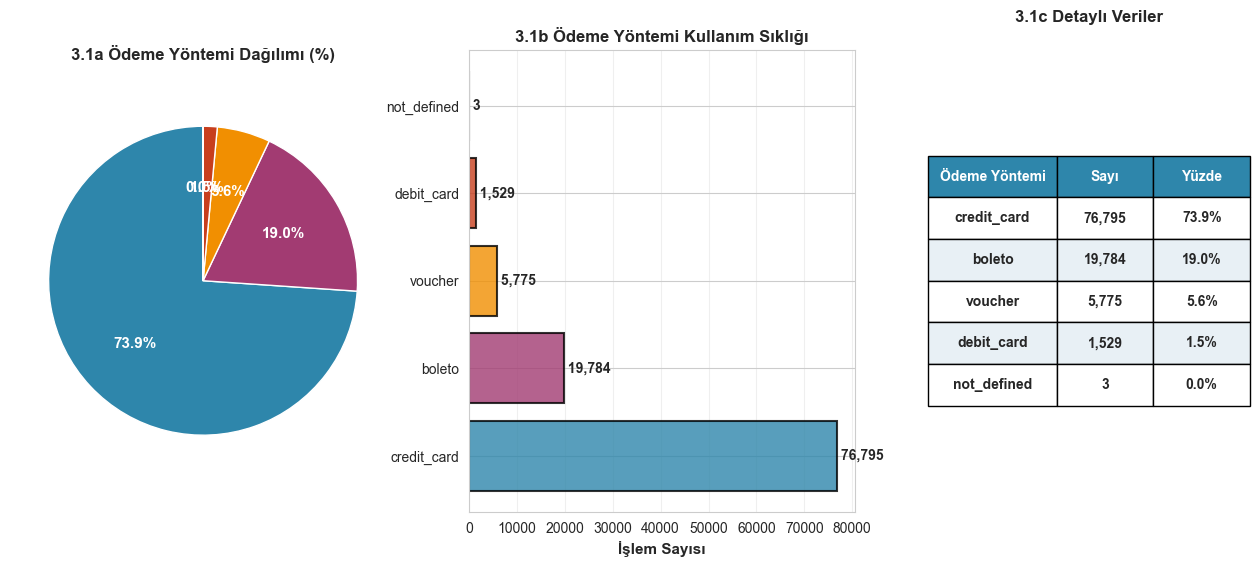

In [46]:
print("\n3.1 Ödeme Yöntemi Dağılımı:")
print(payment_distribution)

fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1.2, 1.2, 1], hspace=0.3)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax_table = fig.add_subplot(gs[2])

# Renkler
colors_payment = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#06A77D']

# ====================================================================
# Pie Chart
# ====================================================================

wedges, texts, autotexts = ax1.pie(payment_distribution['sum_of_payment_type'], 
                                     labels=None,
                                     autopct='%1.1f%%',
                                     colors=colors_payment[:len(payment_distribution)],
                                     startangle=90,
                                     textprops={'fontsize': 11, 'weight': 'bold'})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_weight('bold')

ax1.set_title('3.1a Ödeme Yöntemi Dağılımı (%)', fontsize=12, fontweight='bold', pad=20)

# ====================================================================
# Bar Chart
# ====================================================================

bars = ax2.barh(payment_distribution['payment_type'], 
                payment_distribution['sum_of_payment_type'],
                color=colors_payment[:len(payment_distribution)],
                edgecolor='black', linewidth=1.5, alpha=0.8)

ax2.set_xlabel('İşlem Sayısı', fontsize=11, fontweight='bold')
ax2.set_title('3.1b Ödeme Yöntemi Kullanım Sıklığı', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

for idx, bar in enumerate(bars):
    width = bar.get_width()
    percentage = (width / payment_distribution['sum_of_payment_type'].sum()) * 100
    ax2.text(width, bar.get_y() + bar.get_height()/2.,
            f' {int(width):,}',
            ha='left', va='center', fontsize=10, fontweight='bold')

# ====================================================================
# Tablo
# ====================================================================

table_data = []
for idx, row in payment_distribution.iterrows():
    percentage = (row['sum_of_payment_type'] / payment_distribution['sum_of_payment_type'].sum()) * 100
    table_data.append([
        row['payment_type'],
        f"{row['sum_of_payment_type']:,}",
        f"{percentage:.1f}%"
    ])

table = ax_table.table(cellText=table_data,
                       colLabels=['Ödeme Yöntemi', 'Sayı', 'Yüzde'],
                       cellLoc='center',
                       loc='center',
                       colWidths=[0.4, 0.3, 0.3])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Header rengini ayarla
for i in range(3):
    table[(0, i)].set_facecolor('#2E86AB')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Satırları renklendir
for i in range(1, len(table_data) + 1):
    for j in range(3):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#E8F0F5')
        else:
            table[(i, j)].set_facecolor('#FFFFFF')
        table[(i, j)].set_text_props(weight='bold')

ax_table.axis('off')
ax_table.set_title('3.1c Detaylı Veriler', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('13_payment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


3.2 Ürün Kategorisi ve Ödeme Yöntemi İlişkisi:
       product_category_name payment_type  transaction_count
0                       None       boleto                314
1                       None  credit_card               1220
2                       None   debit_card                 29
3                       None      voucher                116
4  agro_industria_e_comercio       boleto                 60
5  agro_industria_e_comercio  credit_card                145
6  agro_industria_e_comercio   debit_card                  5
7  agro_industria_e_comercio      voucher                 42
8                  alimentos       boleto                106
9                  alimentos  credit_card                381


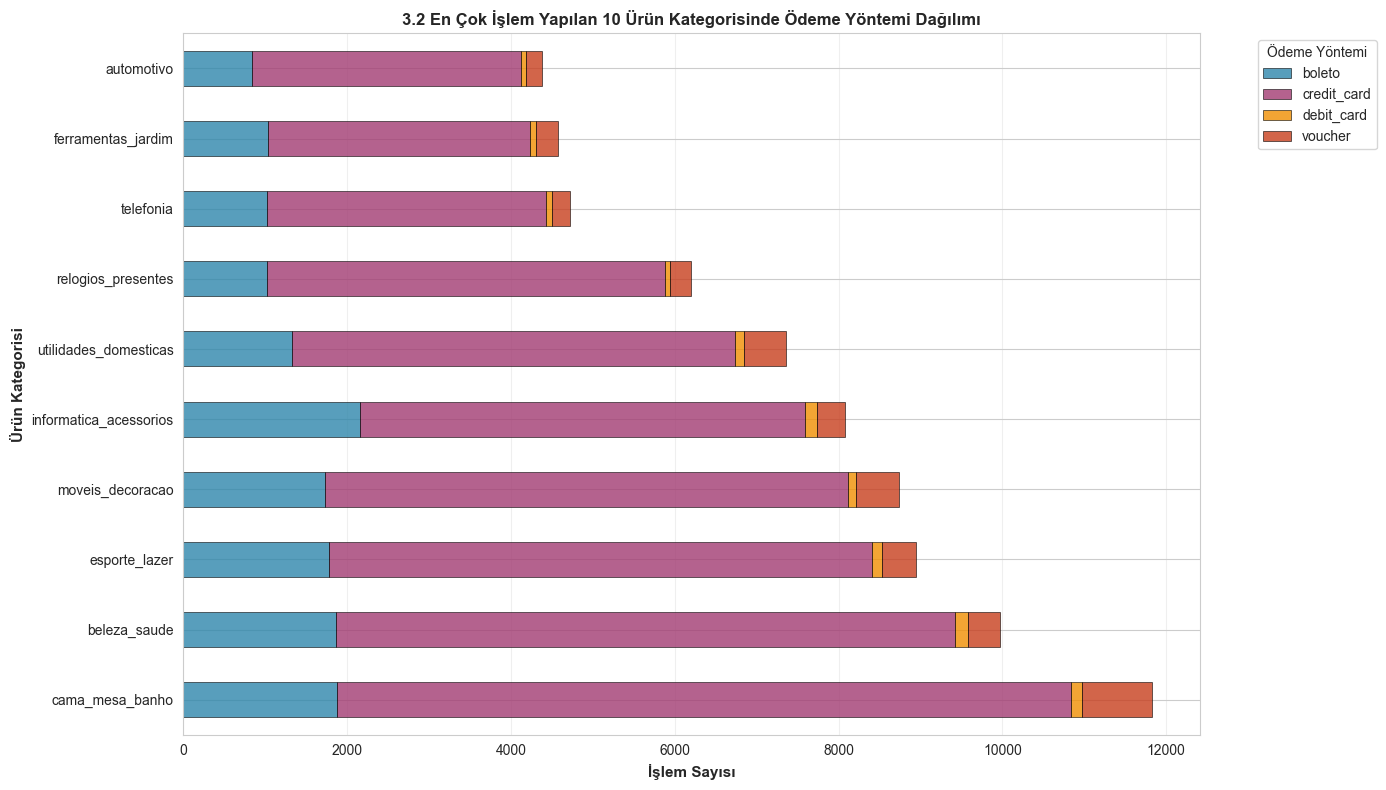

In [47]:
print("\n3.2 Ürün Kategorisi ve Ödeme Yöntemi İlişkisi:")
print(category_payment.head(10))

# Pivot tablo oluştur
category_payment_pivot = category_payment.pivot_table(
    index='product_category_name',
    columns='payment_type',
    values='transaction_count',
    fill_value=0
)

# En çok işlem yapılan 10 kategori seç
top_categories = category_payment.groupby('product_category_name')['transaction_count'].sum().nlargest(10).index
category_payment_pivot_top = category_payment_pivot.loc[top_categories]

fig, ax = plt.subplots(figsize=(14, 8))

category_payment_pivot_top.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=colors_payment[:len(category_payment_pivot_top.columns)],
    edgecolor='black',
    linewidth=0.5,
    alpha=0.8
)

ax.set_xlabel('İşlem Sayısı', fontsize=11, fontweight='bold')
ax.set_ylabel('Ürün Kategorisi', fontsize=11, fontweight='bold')
ax.set_title('3.2 En Çok İşlem Yapılan 10 Ürün Kategorisinde Ödeme Yöntemi Dağılımı', 
             fontsize=12, fontweight='bold')
ax.legend(title='Ödeme Yöntemi', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('14_category_payment_relationship.png', dpi=300, bbox_inches='tight')
plt.show()



3.3 Yıllık Ödeme Yöntemi Dağılımı:
    order_year payment_type  total_payments
0         2016       boleto              63
1         2016  credit_card             258
2         2016   debit_card               2
3         2016      voucher              23
4         2017       boleto            9508
5         2017  credit_card           34565
6         2017   debit_card             422
7         2017      voucher            3027
8         2018       boleto           10213
9         2018  credit_card           41964
10        2018   debit_card            1104
11        2018  not_defined               3
12        2018      voucher            2725


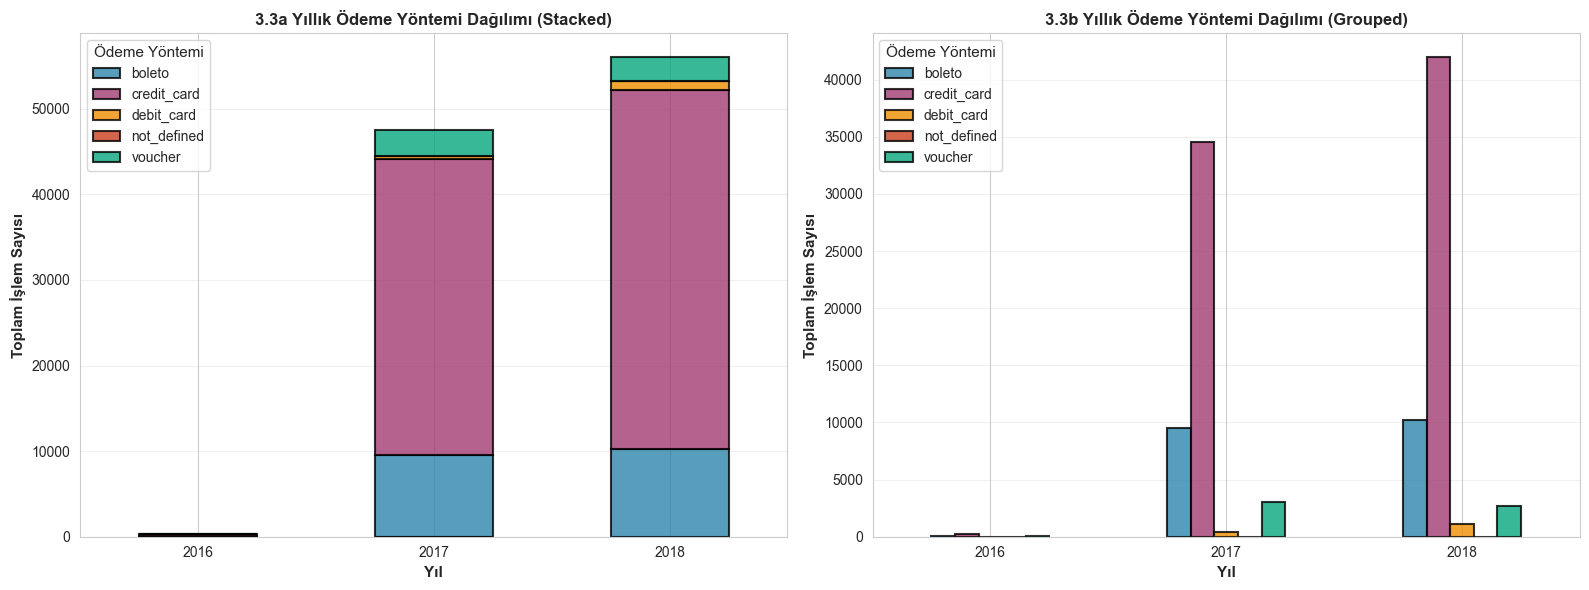

In [48]:
print("\n3.3 Yıllık Ödeme Yöntemi Dağılımı:")
print(yearly_payment)

# Pivot tablo oluştur
yearly_payment_pivot = yearly_payment.pivot_table(
    index='order_year',
    columns='payment_type',
    values='total_payments',
    fill_value=0
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Stacked Bar Chart
yearly_payment_pivot.plot(
    kind='bar',
    stacked=True,
    ax=ax1,
    color=colors_payment[:len(yearly_payment_pivot.columns)],
    edgecolor='black',
    linewidth=1.5,
    alpha=0.8
)

ax1.set_xlabel('Yıl', fontsize=11, fontweight='bold')
ax1.set_ylabel('Toplam İşlem Sayısı', fontsize=11, fontweight='bold')
ax1.set_title('3.3a Yıllık Ödeme Yöntemi Dağılımı (Stacked)', fontsize=12, fontweight='bold')
ax1.legend(title='Ödeme Yöntemi', fontsize=10, title_fontsize=11)
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=0)

# Grouped Bar Chart (Karşılaştırma)
yearly_payment_pivot.plot(
    kind='bar',
    stacked=False,
    ax=ax2,
    color=colors_payment[:len(yearly_payment_pivot.columns)],
    edgecolor='black',
    linewidth=1.5,
    alpha=0.8
)

ax2.set_xlabel('Yıl', fontsize=11, fontweight='bold')
ax2.set_ylabel('Toplam İşlem Sayısı', fontsize=11, fontweight='bold')
ax2.set_title('3.3b Yıllık Ödeme Yöntemi Dağılımı (Grouped)', fontsize=12, fontweight='bold')
ax2.legend(title='Ödeme Yöntemi', fontsize=10, title_fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('15_yearly_payment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


3.4 Ödeme Yöntemi Satış Analizi:
    order_year payment_type  total_sales
0         2016  credit_card     48562.48
1         2016       boleto      9679.06
2         2016      voucher       879.07
3         2016   debit_card       241.73
4         2017  credit_card   5636851.13
5         2017       boleto   1396063.37
6         2017      voucher    172982.95
7         2017   debit_card     43326.47
8         2018  credit_card   6855451.92
9         2018       boleto   1463618.84
10        2018      voucher    205574.85
11        2018   debit_card    174067.35
12        2018  not_defined         0.00


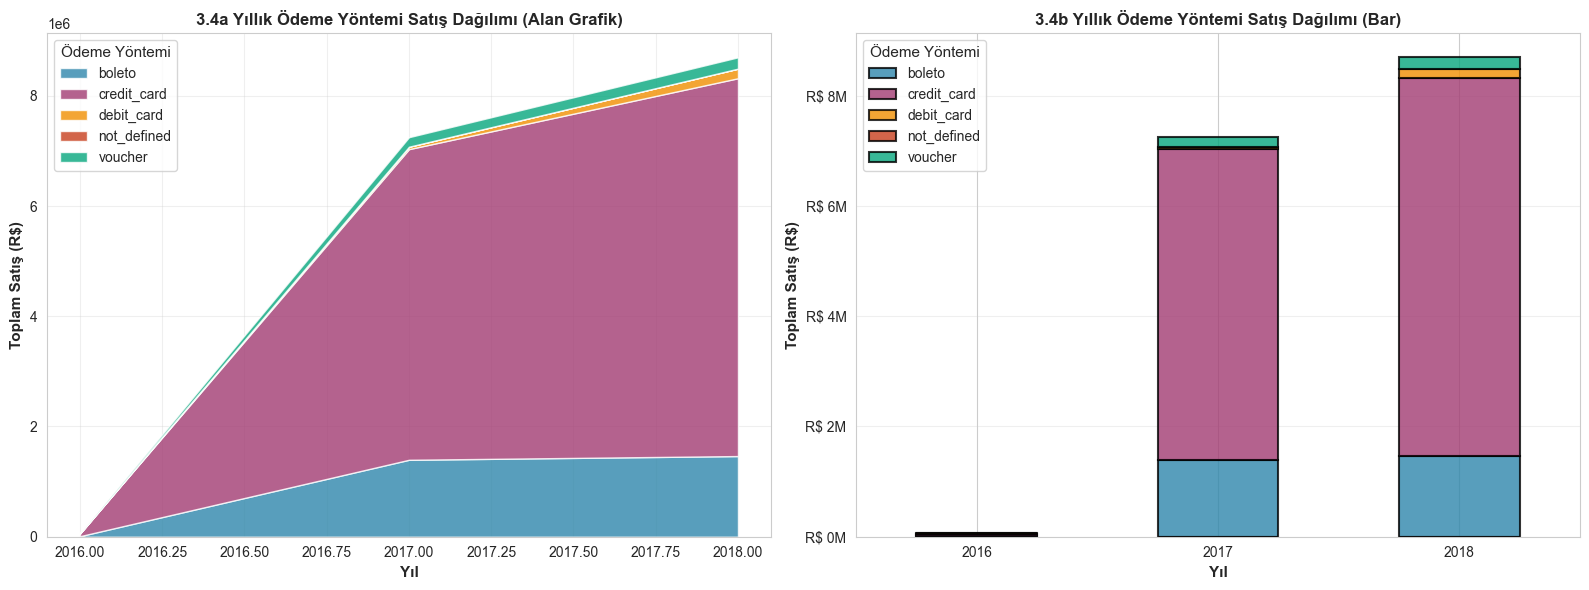

In [49]:
print("\n3.4 Ödeme Yöntemi Satış Analizi:")
print(payment_sales)

# Pivot tablo oluştur
payment_sales_pivot = payment_sales.pivot_table(
    index='order_year',
    columns='payment_type',
    values='total_sales',
    fill_value=0
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Stacked Area Chart
ax1.stackplot(payment_sales_pivot.index, 
              *[payment_sales_pivot[col] for col in payment_sales_pivot.columns],
              labels=payment_sales_pivot.columns,
              colors=colors_payment[:len(payment_sales_pivot.columns)],
              alpha=0.8)

ax1.set_xlabel('Yıl', fontsize=11, fontweight='bold')
ax1.set_ylabel('Toplam Satış (R$)', fontsize=11, fontweight='bold')
ax1.set_title('3.4a Yıllık Ödeme Yöntemi Satış Dağılımı (Alan Grafik)', fontsize=12, fontweight='bold')
ax1.legend(title='Ödeme Yöntemi', fontsize=10, title_fontsize=11, loc='upper left')
ax1.grid(alpha=0.3)

# Stacked Bar Chart
payment_sales_pivot.plot(
    kind='bar',
    stacked=True,
    ax=ax2,
    color=colors_payment[:len(payment_sales_pivot.columns)],
    edgecolor='black',
    linewidth=1.5,
    alpha=0.8
)

ax2.set_xlabel('Yıl', fontsize=11, fontweight='bold')
ax2.set_ylabel('Toplam Satış (R$)', fontsize=11, fontweight='bold')
ax2.set_title('3.4b Yıllık Ödeme Yöntemi Satış Dağılımı (Bar)', fontsize=12, fontweight='bold')
ax2.legend(title='Ödeme Yöntemi', fontsize=10, title_fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=0)

# Y eksenini milyon olarak göster
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x/1e6:.0f}M'))

plt.tight_layout()
plt.savefig('16_payment_sales_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
"""
-- ====================================================================
-- 4. SELLER PERFORMANCE ANALYSIS (SATICI PERFORMANSI ANALİZİ)
-- ====================================================================
"""

query_4_1 = """
SELECT
    a1.Seller_State,
    a1.Seller_City,
    SUM(a2.Price) AS TotalValue
FROM order_seller_clean a1
LEFT JOIN order_items a2
    ON a1.Seller_Id = a2.Seller_Id
GROUP BY
    a1.Seller_State,
    a1.Seller_City
ORDER BY
    TotalValue DESC;
"""

seller_geography = pd.read_sql(query_4_1, engine)


4.1 Satıcı Coğrafi Dağılımı:
   Seller_State            Seller_City  TotalValue
0          SP\r              sao paulo  2702878.14
1          SP\r               ibitinga   624592.94
2          PR\r               curitiba   467821.52
3          RJ\r         rio de janeiro   358126.92
4          SP\r              guarulhos   329494.38
5          SP\r         ribeirao preto   275976.44
6          SP\r        itaquaquecetuba   230568.12
7          SP\r                guariba   229472.63
8          SP\r            santo andre   228561.60
9          BA\r       lauro de freitas   225525.05
10         SP\r             piracicaba   212677.82
11         PR\r                maringa   207257.51
12         SP\r                barueri   196053.17
13         SP\r  sao jose do rio preto   195863.38
14         SP\r                 sumare   195825.21
15         MG\r         belo horizonte   193243.58
16         SP\r  sao bernardo do campo   179363.91
17         SP\r               campinas   179285.45
1

C:\Users\Ali\AppData\Local\Temp\ipykernel_15628\198867731.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  seller_top15['City_State'] = seller_top15['Seller_City'] + ' (' + seller_top15['Seller_State'] + ')'
) missing from font(s) Arial.mp\ipykernel_15628\198867731.py:30: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) Arial.mp\ipykernel_15628\198867731.py:31: UserWarning: Glyph 13 (
  plt.savefig('17_seller_top15_cities.png', dpi=300, bbox_inches='tight')
) missing from font(s) Arial.ograms\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


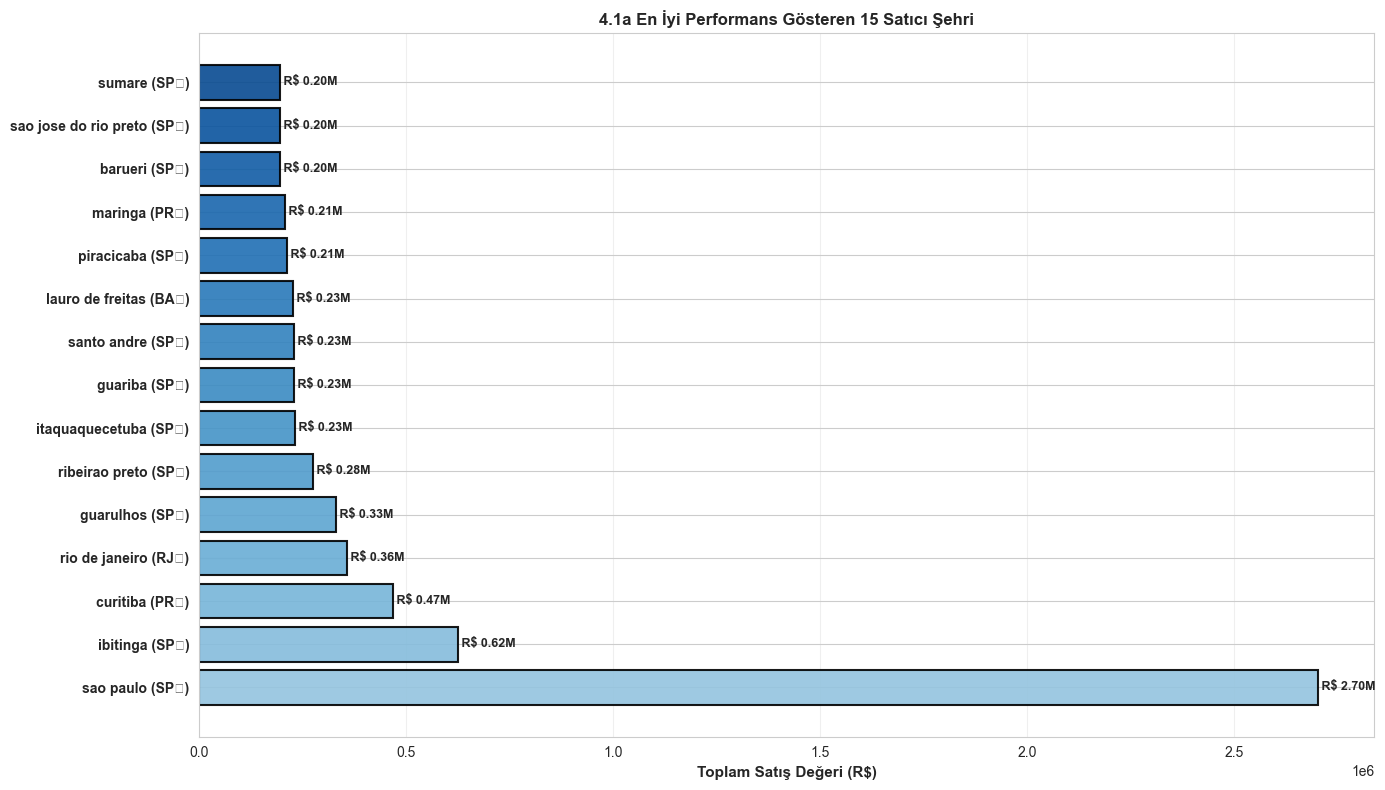

In [53]:
print("\n4.1 Satıcı Coğrafi Dağılımı:")
print(seller_geography.head(20))

# ====================================================================
# 4.1a Top 15 Satıcı Şehri
# ====================================================================

seller_top15 = seller_geography.head(15)
seller_top15['City_State'] = seller_top15['Seller_City'] + ' (' + seller_top15['Seller_State'] + ')'

fig, ax = plt.subplots(figsize=(14, 8))

colors_gradient = plt.cm.Blues(np.linspace(0.4, 0.9, len(seller_top15)))
bars = ax.barh(range(len(seller_top15)), seller_top15['TotalValue'], 
               color=colors_gradient, edgecolor='black', linewidth=1.5, alpha=0.9)

ax.set_yticks(range(len(seller_top15)))
ax.set_yticklabels(seller_top15['City_State'], fontsize=10, fontweight='bold')
ax.set_xlabel('Toplam Satış Değeri (R$)', fontsize=11, fontweight='bold')
ax.set_title('4.1a En İyi Performans Gösteren 15 Satıcı Şehri', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Değerleri bar üzerine yazma
for idx, (bar, value) in enumerate(zip(bars, seller_top15['TotalValue'])):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f' R$ {value/1e6:.2f}M',
            ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('17_seller_top15_cities.png', dpi=300, bbox_inches='tight')
plt.show();

) missing from font(s) Arial.mp\ipykernel_15628\2003816802.py:43: UserWarning: Glyph 13 (
  plt.savefig('20_seller_top20_table.png', dpi=300, bbox_inches='tight')
) missing from font(s) Arial.ograms\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


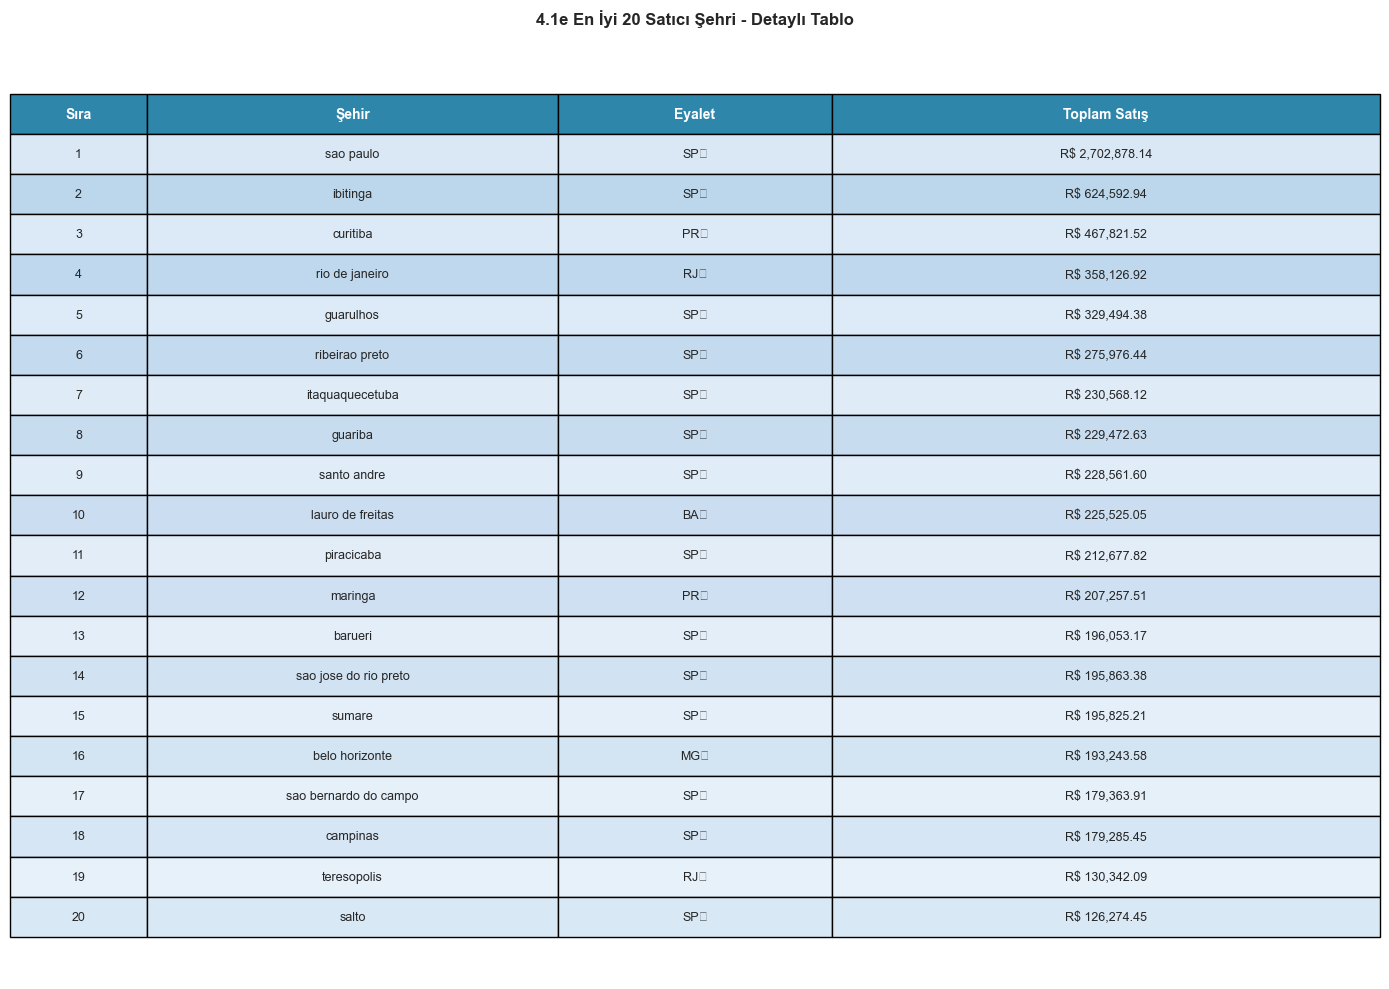

In [55]:
# ====================================================================
# 4.1e Tablo Gösterimi - Top 20 Şehir
# ====================================================================

seller_top20 = seller_geography.head(20)
seller_top20_display = seller_top20[['Seller_City', 'Seller_State', 'TotalValue']].copy()
seller_top20_display['TotalValue'] = seller_top20_display['TotalValue'].apply(lambda x: f'R$ {x:,.2f}')
seller_top20_display.columns = ['Şehir', 'Eyalet', 'Toplam Satış']
seller_top20_display['Sıra'] = range(1, len(seller_top20_display) + 1)
seller_top20_display = seller_top20_display[['Sıra', 'Şehir', 'Eyalet', 'Toplam Satış']]

fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=seller_top20_display.values,
                colLabels=seller_top20_display.columns,
                cellLoc='center',
                loc='center',
                colWidths=[0.1, 0.3, 0.2, 0.4])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Header rengini ayarla
for i in range(len(seller_top20_display.columns)):
    table[(0, i)].set_facecolor('#2E86AB')
    table[(0, i)].set_text_props(weight='bold', color='white', fontsize=10)

# Satırları renklendir (gradient)
for i in range(1, len(seller_top20_display) + 1):
    intensity = 1 - (i / len(seller_top20_display)) * 0.5  # 1.0'dan 0.5'e gradient
    for j in range(len(seller_top20_display.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor(plt.cm.Blues(intensity * 0.3))
        else:
            table[(i, j)].set_facecolor(plt.cm.Blues(intensity * 0.15))

plt.title('4.1e En İyi 20 Satıcı Şehri - Detaylı Tablo', 
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('20_seller_top20_table.png', dpi=300, bbox_inches='tight')
plt.show()